In [1]:


from pathlib import Path

import os
import numpy as np
import matplotlib.pyplot as plt

import SimpleITK as sitk
import nibabel as nib

import torch

In [2]:


PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

LITS_DIR = DATA_DIR / "LiTS17"
MSD_DIR = DATA_DIR / "Task03_Liver"
TCGA_DIR = DATA_DIR / "tcga_lihc"

PROCESSED_DIR = PROJECT_ROOT / "datasets" / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)

c:\Users\shreyas\OneDrive\Desktop\1BM22CS270_Shreyas_Gouda_M


In [3]:

def load_lits(path):
    image = sitk.ReadImage(str(path))
    volume = sitk.GetArrayFromImage(image)
    return image, volume


def load_msd(path):
    image = sitk.ReadImage(str(path))
    volume = sitk.GetArrayFromImage(image)
    return image, volume


def load_tcga_patient(patient_folder):

    patient_folder = Path(patient_folder)

    study = sorted(
        [f for f in patient_folder.iterdir() if f.is_dir()]
    )[0]

    series = sorted(
        [f for f in study.iterdir() if f.is_dir()]
    )[0]

    reader = sitk.ImageSeriesReader()

    dicom_names = reader.GetGDCMSeriesFileNames(
        str(series)
    )

    reader.SetFileNames(dicom_names)

    image = reader.Execute()

    volume = sitk.GetArrayFromImage(image)

    return image, volume

In [4]:

# HU Clipping

def clip_hu(volume, hu_min=-100, hu_max=400):

    volume = np.clip(volume, hu_min, hu_max)

    return volume



# Min-Max Normalization


def normalize(volume):

    volume = volume.astype(np.float32)

    volume = (volume + 100) / 500.0

    volume = np.clip(volume, 0.0, 1.0)

    return volume

In [5]:
lits_file = sorted(
    LITS_DIR.glob("volume-*.nii")
)[0]

image, volume = load_lits(lits_file)

print("Original")

print(volume.shape)

print(volume.min())

print(volume.max())

clipped = clip_hu(volume)

normalized = normalize(clipped)

print()

print("After preprocessing")

print(normalized.min())

print(normalized.max())

Original
(75, 512, 512)
-3024.0
1410.0

After preprocessing
0.0
1.0


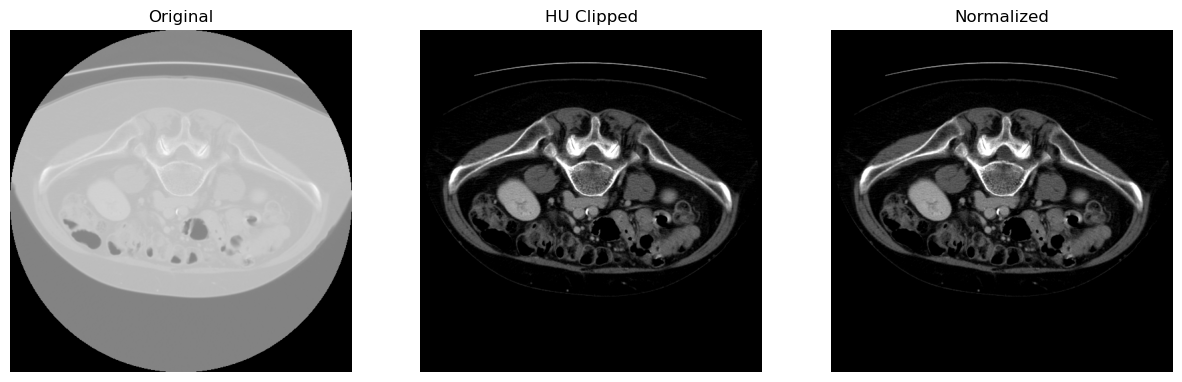

In [6]:
mid = volume.shape[0] // 2

fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(volume[mid], cmap="gray")
ax[0].set_title("Original")

ax[1].imshow(clipped[mid], cmap="gray")
ax[1].set_title("HU Clipped")

ax[2].imshow(normalized[mid], cmap="gray")
ax[2].set_title("Normalized")

for a in ax:
    a.axis("off")

plt.show()

In [7]:
# ============================================================
# Resample Volume
# ============================================================

def resample_image(image, new_spacing=(1.0, 1.0, 1.0)):

    original_spacing = image.GetSpacing()
    original_size = image.GetSize()

    new_size = [
        int(round(original_size[i] * (original_spacing[i] / new_spacing[i])))
        for i in range(3)
    ]

    resampler = sitk.ResampleImageFilter()

    resampler.SetInterpolator(sitk.sitkLinear)

    resampler.SetOutputSpacing(new_spacing)
    resampler.SetSize(new_size)

    resampler.SetOutputDirection(image.GetDirection())
    resampler.SetOutputOrigin(image.GetOrigin())

    resampler.SetTransform(sitk.Transform())

    resampled = resampler.Execute(image)

    return resampled

In [8]:
# Original image
image, volume = load_lits(lits_file)

print("Original")
print("Spacing :", image.GetSpacing())
print("Size    :", image.GetSize())

# Resample
resampled_image = resample_image(image)

resampled_volume = sitk.GetArrayFromImage(resampled_image)

print("\nAfter Resampling")
print("Spacing :", resampled_image.GetSpacing())
print("Size    :", resampled_image.GetSize())

Original
Spacing : (0.703125, 0.703125, 5.0)
Size    : (512, 512, 75)

After Resampling
Spacing : (1.0, 1.0, 1.0)
Size    : (360, 360, 375)


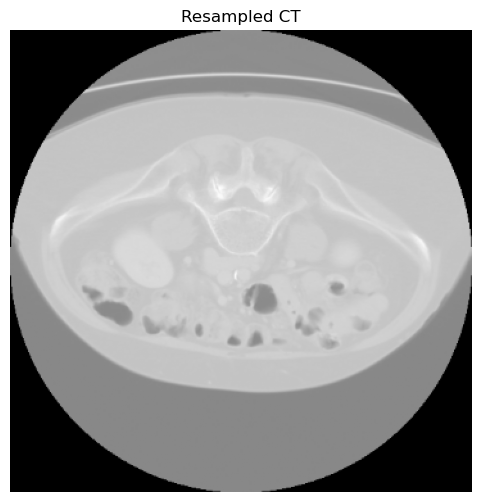

In [9]:
mid = resampled_volume.shape[0] // 2

plt.figure(figsize=(6,6))
plt.imshow(resampled_volume[mid], cmap="gray")
plt.title("Resampled CT")
plt.axis("off")
plt.show()

In [10]:
# ============================================================
# Complete Preprocessing Pipeline
# ============================================================

def preprocess_volume(image):

    # Convert to NumPy
    volume = sitk.GetArrayFromImage(image)

    # HU clipping
    volume = clip_hu(volume)

    # Normalization
    volume = normalize(volume)

    # Resample
    image = sitk.GetImageFromArray(volume)

    image.SetSpacing((1.0, 1.0, 1.0))

    image = resample_image(image)

    volume = sitk.GetArrayFromImage(image)

    return image, volume

In [11]:
image, volume = load_lits(lits_file)

processed_image, processed_volume = preprocess_volume(image)

print(processed_volume.shape)

print(processed_volume.min())

print(processed_volume.max())

(75, 512, 512)
0.0
1.0


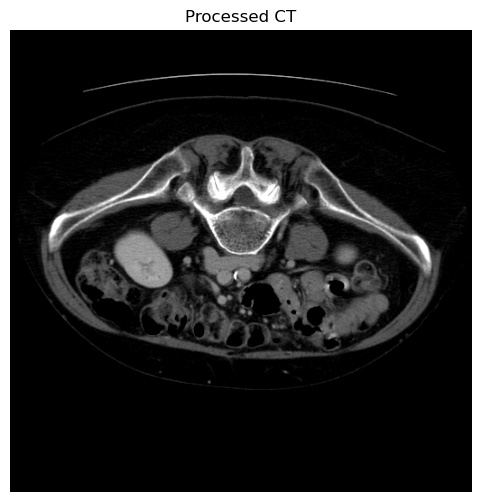

In [12]:
mid = processed_volume.shape[0] // 2

plt.figure(figsize=(6,6))

plt.imshow(processed_volume[mid], cmap="gray")

plt.title("Processed CT")

plt.axis("off")

plt.show()

In [13]:
# ============================================================
# Save Processed Volume
# ============================================================

def save_volume(image, filename):

    sitk.WriteImage(image, str(filename))

    print(f"Saved -> {filename}")

In [14]:
processed_dir = PROCESSED_DIR / "LiTS17"

processed_dir.mkdir(parents=True, exist_ok=True)

save_volume(
    processed_image,
    processed_dir / lits_file.name
)

Saved -> c:\Users\shreyas\OneDrive\Desktop\1BM22CS270_Shreyas_Gouda_M\datasets\processed\LiTS17\volume-0.nii


In [15]:
"""
Dataset loading utilities.

Supports

1. LiTS17 (.nii)

2. MSD Task03 (.nii.gz)

3. TCGA-LIHC (DICOM)
"""

from pathlib import Path

import SimpleITK as sitk


# ---------------------------------------------------------
# LiTS
# ---------------------------------------------------------

def load_lits(path):

    image = sitk.ReadImage(str(path))

    volume = sitk.GetArrayFromImage(image)

    return image, volume


# ---------------------------------------------------------
# MSD
# ---------------------------------------------------------

def load_msd(path):

    image = sitk.ReadImage(str(path))

    volume = sitk.GetArrayFromImage(image)

    return image, volume


# ---------------------------------------------------------
# TCGA
# ---------------------------------------------------------

def load_tcga_patient(patient_folder):

    patient_folder = Path(patient_folder)

    studies = sorted(
        [f for f in patient_folder.iterdir() if f.is_dir()]
    )

    if len(studies) == 0:

        raise RuntimeError(
            f"No studies found for {patient_folder}"
        )

    study = studies[0]

    series = sorted(
        [f for f in study.iterdir() if f.is_dir()]
    )

    if len(series) == 0:

        raise RuntimeError(
            f"No series found for {study}"
        )

    series = series[0]

    reader = sitk.ImageSeriesReader()

    dicom_names = reader.GetGDCMSeriesFileNames(
        str(series)
    )

    reader.SetFileNames(dicom_names)

    image = reader.Execute()

    volume = sitk.GetArrayFromImage(image)

    return image, volume

In [16]:
# ============================================================
# 02_preprocessing.ipynb
# Production Version
# ============================================================

from pathlib import Path
import os

import numpy as np
import matplotlib.pyplot as plt

import SimpleITK as sitk
import nibabel as nib

import cv2

from scipy.ndimage import zoom

print("All libraries imported successfully.")

All libraries imported successfully.


In [17]:
# ============================================================
# Project Paths
# ============================================================

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"

LITS_DIR = DATA_DIR / "LiTS17"
MSD_DIR = DATA_DIR / "Task03_Liver"
TCGA_DIR = DATA_DIR / "tcga_lihc"

PROCESSED_DIR = PROJECT_ROOT / "datasets" / "processed"

LITS_OUT = PROCESSED_DIR / "LiTS17"
MSD_OUT = PROCESSED_DIR / "Task03_Liver"
TCGA_OUT = PROCESSED_DIR / "TCGA_LIHC"

LITS_OUT.mkdir(parents=True, exist_ok=True)
MSD_OUT.mkdir(parents=True, exist_ok=True)
TCGA_OUT.mkdir(parents=True, exist_ok=True)

print(PROJECT_ROOT)

c:\Users\shreyas\OneDrive\Desktop\1BM22CS270_Shreyas_Gouda_M


In [18]:
# ============================================================
# Dataset Loaders
# ============================================================

def load_lits(path):

    image = sitk.ReadImage(str(path))

    return image


def load_msd(path):

    image = sitk.ReadImage(str(path))

    return image


def load_tcga_patient(patient_folder):

    patient_folder = Path(patient_folder)

    studies = sorted(
        [f for f in patient_folder.iterdir() if f.is_dir()]
    )

    if len(studies) == 0:
        raise RuntimeError("No study found.")

    study = studies[0]

    series = sorted(
        [f for f in study.iterdir() if f.is_dir()]
    )

    if len(series) == 0:
        raise RuntimeError("No series found.")

    series = series[0]

    reader = sitk.ImageSeriesReader()

    dicom_files = reader.GetGDCMSeriesFileNames(str(series))

    reader.SetFileNames(dicom_files)

    image = reader.Execute()

    return image

In [19]:
# ============================================================
# Image Information
# ============================================================

def print_image_info(image):

    volume = sitk.GetArrayFromImage(image)

    print("=" * 60)

    print("Size       :", image.GetSize())
    print("Spacing    :", image.GetSpacing())
    print("Origin     :", image.GetOrigin())
    print("Direction  :", image.GetDirection())

    print()

    print("Shape      :", volume.shape)
    print("Datatype   :", volume.dtype)

    print("Minimum HU :", volume.min())
    print("Maximum HU :", volume.max())

    print("=" * 60)

In [20]:
# ------------------------------------------------------------
# LiTS
# ------------------------------------------------------------

lits_file = sorted(LITS_DIR.glob("volume-*.nii"))[0]

lits_image = load_lits(lits_file)

print("LiTS")
print_image_info(lits_image)

# ------------------------------------------------------------
# MSD
# ------------------------------------------------------------

msd_file = sorted((MSD_DIR / "imagesTr").glob("*.nii.gz"))[0]

msd_image = load_msd(msd_file)

print("MSD")
print_image_info(msd_image)

# ------------------------------------------------------------
# TCGA
# ------------------------------------------------------------

patient = sorted(
    [p for p in TCGA_DIR.iterdir() if p.is_dir()]
)[0]

tcga_image = load_tcga_patient(patient)

print("TCGA")
print_image_info(tcga_image)

LiTS
Size       : (512, 512, 75)
Spacing    : (0.703125, 0.703125, 5.0)
Origin     : (-172.89999389648438, 179.296875, -368.0)
Direction  : (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)

Shape      : (75, 512, 512)
Datatype   : float32
Minimum HU : -3024.0
Maximum HU : 1410.0
MSD
Size       : (512, 512, 75)
Spacing    : (0.703125, 0.703125, 5.0)
Origin     : (186.39688110351562, 179.296875, -368.0)
Direction  : (-1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)

Shape      : (75, 512, 512)
Datatype   : float32
Minimum HU : -1024.0
Maximum HU : 1410.0
TCGA
Size       : (256, 208, 35)
Spacing    : (1.484375, 1.484375, 7.260000116684853)
Origin     : (-199.55852985382, -181.38074684143, -87.766609191895)
Direction  : (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)

Shape      : (35, 208, 256)
Datatype   : uint16
Minimum HU : 0
Maximum HU : 277


In [21]:
# ============================================================
# HU Clipping
# ============================================================

def clip_hu(image,
            hu_min=-100,
            hu_max=400):

    volume = sitk.GetArrayFromImage(image)

    volume = np.clip(
        volume,
        hu_min,
        hu_max
    )

    clipped = sitk.GetImageFromArray(volume)

    # Preserve metadata
    clipped.CopyInformation(image)

    return clipped

In [22]:
# ============================================================
# Normalization
# ============================================================

def normalize(image):

    volume = sitk.GetArrayFromImage(image)

    volume = volume.astype(np.float32)

    volume = (volume + 100.0) / 500.0

    volume = np.clip(
        volume,
        0.0,
        1.0
    )

    normalized = sitk.GetImageFromArray(volume)

    normalized.CopyInformation(image)

    return normalized

In [23]:
# ============================================================
# Resampling
# ============================================================

def resample_image(image,
                   spacing=(1.0,1.0,1.0)):

    original_spacing = image.GetSpacing()

    original_size = image.GetSize()

    new_size = [

        int(round(

            original_size[i] *

            original_spacing[i] /

            spacing[i]

        ))

        for i in range(3)

    ]

    resampler = sitk.ResampleImageFilter()

    resampler.SetInterpolator(
        sitk.sitkLinear
    )

    resampler.SetOutputSpacing(
        spacing
    )

    resampler.SetSize(
        new_size
    )

    resampler.SetOutputDirection(
        image.GetDirection()
    )

    resampler.SetOutputOrigin(
        image.GetOrigin()
    )

    resampler.SetTransform(
        sitk.Transform()
    )

    return resampler.Execute(image)

In [24]:
# ============================================================
# Complete Pipeline
# ============================================================

def preprocess(image):

    image = clip_hu(image)

    image = normalize(image)

    image = resample_image(image)

    return image

In [25]:
processed = preprocess(lits_image)

print("Processed")

print_image_info(processed)

Processed
Size       : (360, 360, 375)
Spacing    : (1.0, 1.0, 1.0)
Origin     : (-172.89999389648438, 179.296875, -368.0)
Direction  : (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)

Shape      : (375, 360, 360)
Datatype   : float32
Minimum HU : 0.0
Maximum HU : 1.0


In [26]:
# ============================================================
# Final Preprocessing Pipeline
# ============================================================

def preprocess(image):

    # Step 1
    image = resample_image(image)

    # Step 2
    image = clip_hu(image)

    # Step 3
    image = normalize(image)

    return image

In [27]:
# ============================================================
# Save Image
# ============================================================

def save_image(image, filename):

    sitk.WriteImage(
        image,
        str(filename)
    )

    print(f"Saved : {filename}")

In [28]:
processed = preprocess(lits_image)

save_path = LITS_OUT / "volume-0.nii"

save_image(
    processed,
    save_path
)

Saved : c:\Users\shreyas\OneDrive\Desktop\1BM22CS270_Shreyas_Gouda_M\datasets\processed\LiTS17\volume-0.nii


In [29]:
reloaded = sitk.ReadImage(str(save_path))

print("Reloaded Image")

print_image_info(reloaded)

Reloaded Image
Size       : (360, 360, 375)
Spacing    : (1.0, 1.0, 1.0)
Origin     : (-172.89999389648438, 179.296875, -368.0)
Direction  : (1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0, 0.0, 1.0)

Shape      : (375, 360, 360)
Datatype   : float32
Minimum HU : 0.0
Maximum HU : 1.0


In [30]:
def load_tcga_patient(patient_folder):

    patient_folder = Path(patient_folder)

    preferred_keywords = [
        "venous",
        "portal",
        "abd/pelvis",
        "abdpelvis",
        "abdomen",
        "arterial",
        "target/lung/liver"
    ]

    ignore_keywords = [
        "localizer",
        "topogram",
        "scout",
        "mip",
        "reformats",
        "cor",
        "sag"
    ]

    best_series = None
    best_score = -1

    for study in sorted(patient_folder.iterdir()):

        if not study.is_dir():
            continue

        for series in sorted(study.iterdir()):

            if not series.is_dir():
                continue

            dicom_files = sorted(series.glob("*.dcm"))

            if len(dicom_files) == 0:
                continue

            try:

                ds = pydicom.dcmread(
                    dicom_files[0],
                    stop_before_pixels=True
                )

                # Ignore non-CT
                if ds.get("Modality", "") != "CT":
                    continue

                description = str(
                    ds.get("SeriesDescription", "")
                ).lower()

                # Ignore scout/localizer/MIP/etc.
                if any(k in description for k in ignore_keywords):
                    continue

                score = 0

                for k in preferred_keywords:

                    if k in description:
                        score += 10

                score += len(dicom_files)

                if score > best_score:

                    best_score = score

                    best_series = series

            except:
                continue

    if best_series is None:
        raise RuntimeError(
            f"No suitable CT series found for {patient_folder.name}"
        )

    reader = sitk.ImageSeriesReader()

    dicom_names = reader.GetGDCMSeriesFileNames(
        str(best_series)
    )

    reader.SetFileNames(dicom_names)

    image = reader.Execute()

    return image

In [31]:
import pydicom

In [39]:
def load_tcga_patient(patient_folder):
    """
    Load the best CT series for a TCGA patient.

    Returns
    -------
    image : SimpleITK.Image or None
    patient_id : str
    study_id : str
    series_id : str
    series_description : str
    num_slices : int
    spacing : tuple
    """

    patient_folder = Path(patient_folder)

    preferred_keywords = [
        "venous",
        "portal",
        "portal venous",
        "abd/pelvis",
        "abdpelvis",
        "abdomen",
        "arterial",
        "target/lung/liver"
    ]

    ignore_keywords = [
        "localizer",
        "topogram",
        "scout",
        "mip",
        "reformats",
        "cor",
        "sag",
        "3d",
        "mpr"
    ]

    best_series = None
    best_score = -1

    best_description = "Unknown"
    best_study = "Unknown"
    best_series_id = "Unknown"

    # -------------------------------------------------------
    # Search every study
    # -------------------------------------------------------
    for study in sorted(patient_folder.iterdir()):

        if not study.is_dir():
            continue

        # -----------------------------------------------
        # Search every series
        # -----------------------------------------------
        for series in sorted(study.iterdir()):

            if not series.is_dir():
                continue

            dicom_files = sorted(series.glob("*.dcm"))

            if len(dicom_files) == 0:
                continue

            try:

                ds = pydicom.dcmread(
                    dicom_files[0],
                    stop_before_pixels=True
                )

                modality = str(
                    ds.get("Modality", "")
                ).upper()

                # ---------------------------------------
                # Only CT
                # ---------------------------------------
                if modality != "CT":
                    continue

                description = str(
                    ds.get("SeriesDescription", "")
                ).lower()

                # ---------------------------------------
                # Ignore unwanted series
                # ---------------------------------------
                if any(
                    keyword in description
                    for keyword in ignore_keywords
                ):
                    continue

                score = len(dicom_files)

                # Prefer abdominal diagnostic CT
                for keyword in preferred_keywords:

                    if keyword in description:

                        score += 100

                # Prefer larger series
                score += len(dicom_files)

                if score > best_score:

                    best_score = score

                    best_series = series

                    best_description = ds.get(
                        "SeriesDescription",
                        "Unknown"
                    )

                    best_study = study.name

                    best_series_id = series.name

            except Exception as e:

                print(
                    f"[WARNING] Skipping {series.name}: {e}"
                )

                continue

    # -------------------------------------------------------
    # No suitable CT found
    # -------------------------------------------------------
    if best_series is None:

        print(
            f"[WARNING] No suitable CT found for {patient_folder.name}"
        )

        return (
            None,
            patient_folder.name,
            None,
            None,
            None,
            0,
            None
        )

    # -------------------------------------------------------
    # Load selected CT series
    # -------------------------------------------------------
    reader = sitk.ImageSeriesReader()

    dicom_names = reader.GetGDCMSeriesFileNames(
        str(best_series)
    )

    reader.SetFileNames(dicom_names)

    image = reader.Execute()

    return (

        image,

        patient_folder.name,

        best_study,

        best_series_id,

        best_description,

        len(dicom_names),

        image.GetSpacing()

    )

In [41]:
patient = TCGA_DIR / "TCGA-BC-A10W"

(
    tcga_image,
    patient_id,
    study_id,
    series_id,
    series_description,
    num_slices,
    spacing
) = load_tcga_patient(patient)

if tcga_image is not None:

    print("=" * 70)

    print(f"Patient ID         : {patient_id}")
    print(f"Study ID           : {study_id}")
    print(f"Series ID          : {series_id}")
    print(f"Series Description : {series_description}")
    print(f"Number of Slices   : {num_slices}")
    print(f"Voxel Spacing      : {spacing}")

    print("=" * 70)

    print_image_info(tcga_image)

else:

    print(f"Skipping {patient_id}")

Patient ID         : TCGA-BC-A10W
Study ID           : 26053
Series ID          : 24744
Series Description : 150cc OMNIPAQUE)
Number of Slices   : 60
Voxel Spacing      : (0.6953125, 0.6953125, 8.0)
Size       : (512, 512, 60)
Spacing    : (0.6953125, 0.6953125, 8.0)
Origin     : (-170.0, -182.0, -1392.0)
Direction  : (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0)

Shape      : (60, 512, 512)
Datatype   : int16
Minimum HU : -1024
Maximum HU : 1503
